# Isolation Forest for Anomaly Detection

In [1]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler 
import  matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("thyroid_dataset.csv")
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [3]:
X = df.drop("Outlier_label", axis=1)
y = df["Outlier_label"]

In [4]:
scaler = StandardScaler() 

X_scaled = scaler.fit_transform(X) 

In [5]:
from sklearn.ensemble import IsolationForest

tree = IsolationForest(n_estimators=200, contamination=0.036, random_state=42) 

In [6]:
labels = tree.fit_predict(X_scaled)

In [7]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'PC2')

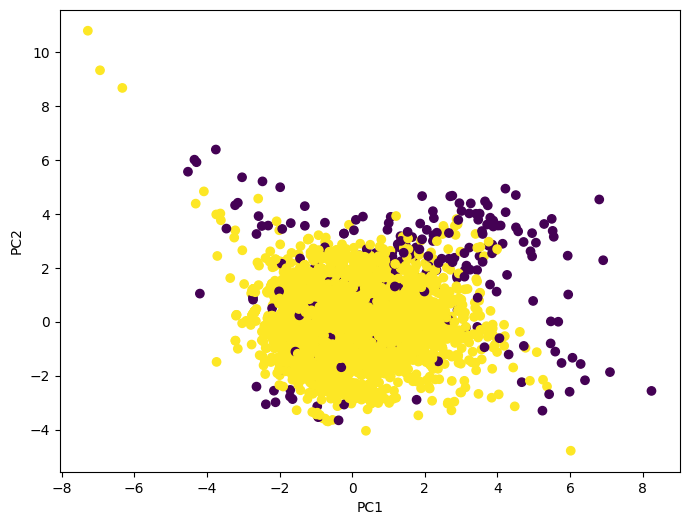

In [8]:
plt.figure(figsize=(8, 6)) 

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels) 
plt.xlabel("PC1") 
plt.ylabel("PC2")

In [9]:
import numpy as np 

n_outliers = np.sum(labels == -1) 
n_normal = np.sum(labels == 1) 

print("outlier: ", n_outliers)
print("normal: ", n_normal)

outlier:  249
normal:  6667
